# CNOT baseline buffer scan analysis

This notebook analyzes different buffer depths.

In [3]:
%load_ext autoreload
%autoreload 2

from itertools import product
from pathlib import Path

from IPython.display import Markdown, display

from analysis_utils import (
    plot_finite_size_scaling_fit,
    display_fit_summary,
    fit_finite_size_scaling,
    load_ft_scan,
    plot_rate_scan,
)

RESULT_ROOT = Path("../results/baseline/ft/buffer_scan")
UPDATE_TIME = [1]
CLEANUP_TIME = [2]
BUFFER_DEPTH = [1, 2, 3, 4, 5]
P_VALUES = [0.010, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020]
L_VALUES = [5, 7, 9, 13, 19]

# Change this positive integer to adjust the scaling-polynomial degree.
FIT_DEGREE = 4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Per-combination analysis

### update_1L_cleanup_2L_buffer_1xlog1.5L

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


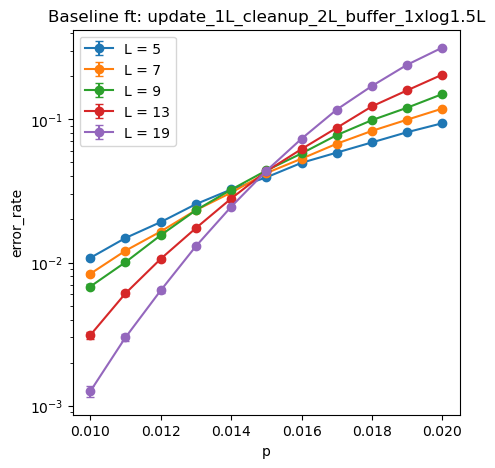

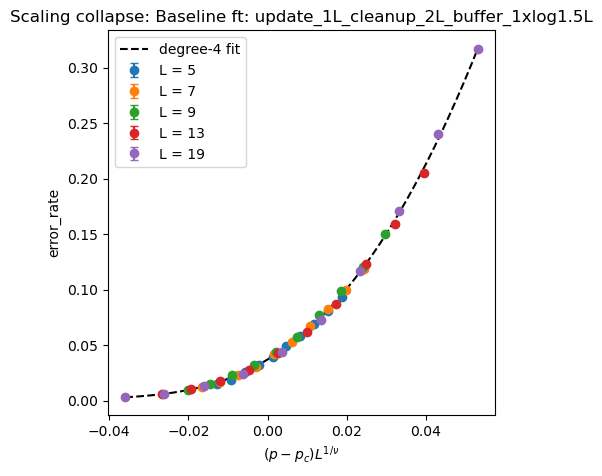

### update_1L_cleanup_2L_buffer_2xlog1.5L

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


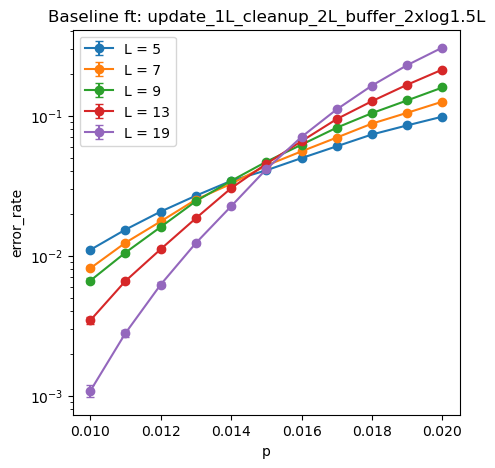

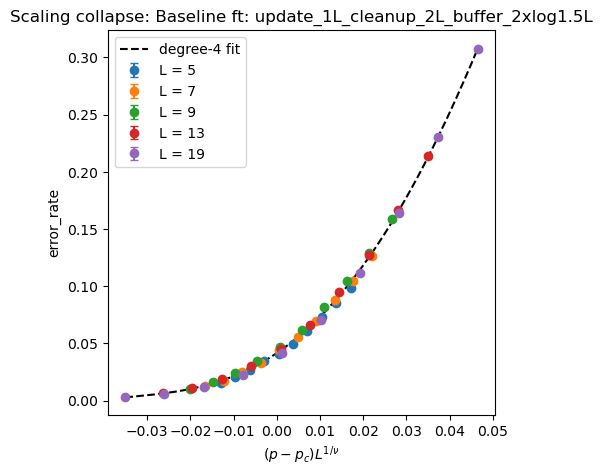

### update_1L_cleanup_2L_buffer_3xlog1.5L

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


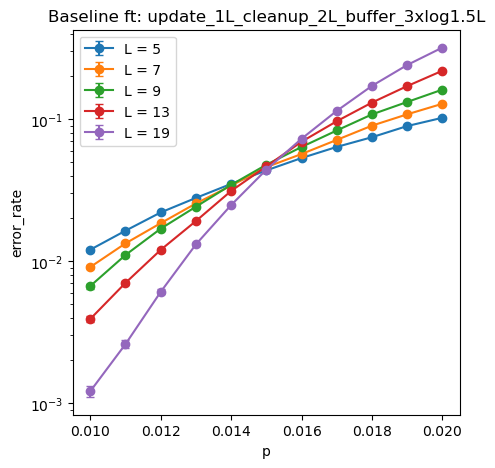

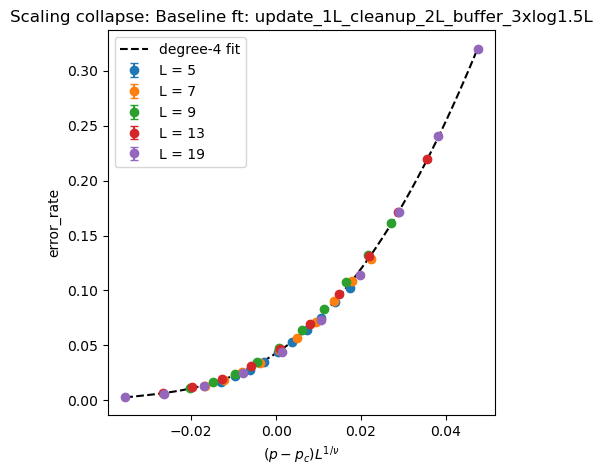

### update_1L_cleanup_2L_buffer_4xlog1.5L

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


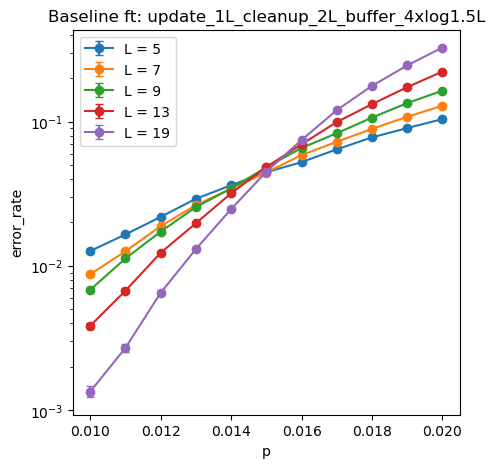

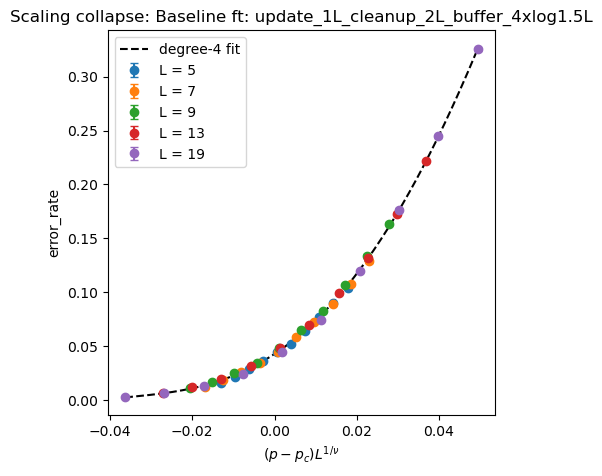

### update_1L_cleanup_2L_buffer_5xlog1.5L

Loaded 55 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


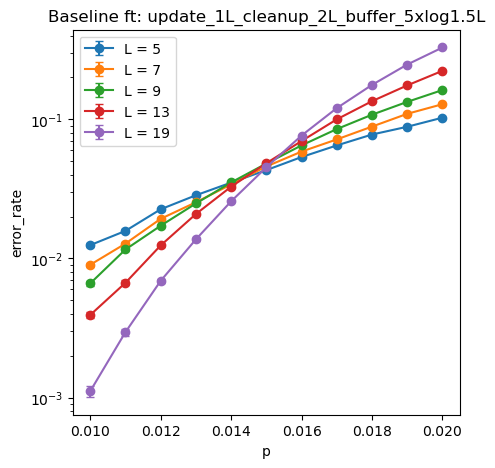

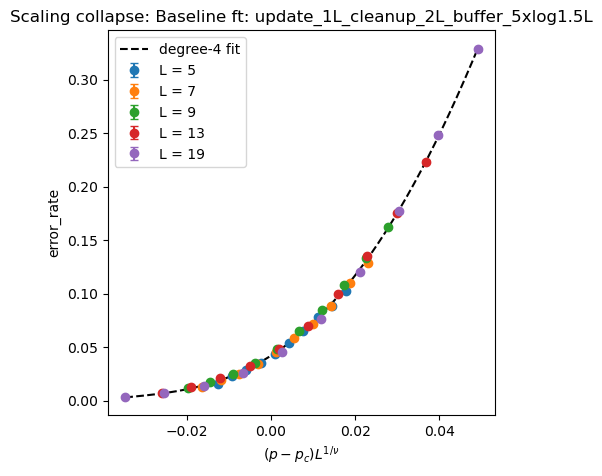

In [4]:
scans = {}
fits = {}

for update_time, cleanup_time, buffer_depth in product(
    UPDATE_TIME, CLEANUP_TIME, BUFFER_DEPTH
):
    combination = f"update_{update_time}L_cleanup_{cleanup_time}L_buffer_{buffer_depth}xlog1.5L"
    display(Markdown(f"### {combination}"))

    scan = load_ft_scan(
        RESULT_ROOT / combination,
        p_values=P_VALUES,
        L_values=L_VALUES,
        expected_repeats=1,
        result_pattern="2d_Ft*.txt",
        success_field="Ft",
        scan_label="Ft",
    )
    scans[combination] = scan
    scan.print_summary()

    plot_rate_scan(
        scan,
        title=f"Baseline ft: {combination}",
        ylabel="error_rate",
    )

    fit = fit_finite_size_scaling(
        scan,
        label=f"Baseline ft: {combination}",
        polynomial_degree=FIT_DEGREE,
    )
    fits[combination] = fit
    plot_finite_size_scaling_fit(fit, "error_rate")

## All-combination fit summary

In [3]:
display_fit_summary(
    list(fits.values()),
    title="Baseline fit summary: all timing combinations",
    include_degree=False,
    include_decimal_pc=False,
)

## Baseline fit summary: all timing combinations

| Timing and block | $p_c$ (%) | $\nu$ | $\chi^2 / \mathrm{dof}$ | fit $p$-value |
|---|---:|---:|---:|---:|
| Baseline ft: update_1L_cleanup_2L_buffer_1xlog1.5L | 1.464(2) | 1.28(1) | 5.40 | 9.25e-28 |
| Baseline ft: update_1L_cleanup_2L_buffer_2xlog1.5L | 1.487(2) | 1.34(1) | 10.82 | 3.22e-72 |
| Baseline ft: update_1L_cleanup_2L_buffer_3xlog1.5L | 1.486(2) | 1.32(1) | 7.48 | 2.55e-44 |
| Baseline ft: update_1L_cleanup_2L_buffer_4xlog1.5L | 1.481(2) | 1.31(1) | 7.58 | 3.62e-45 |
| Baseline ft: update_1L_cleanup_2L_buffer_5xlog1.5L | 1.472(2) | 1.32(1) | 8.45 | 2.78e-52 |